In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import levy_stable
import powerlaw
import math
from datetime import datetime

def pl_fit(data):
    """
    Calculate exponent of powerlaw and standard deviation of parameter uncertainty for alpha
    """
    result = powerlaw.Fit(data).power_law
    alpha = result.alpha
    sigma = result.sigma

    return alpha, sigma

def crit_params(data):
    """
    Fit data to Levy stable distribution and output alpha and beta estimates.
    """

    alpha_est, beta_est, loc_est, scale_est = levy_stable.fit(data)
    return alpha_est, beta_est

In [93]:
# Extract raw CSV data 
months = ['2024-05','2024-06','2024-07','2024-08','2024-09',
          '2024-10','2024-11','2024-12','2025-01','2025-02',
          '2025-03','2025-04','2025-05','2025-06','2025-07',
          '2025-08','2025-09','2025-10','2025-11','2025-12',
          '2026-01','2026-02','2026-03','2026-04','2026-05',
          '2026-06']

for i, month in enumerate(months):
    if i == 0:
        df = pd.read_csv('Data/BTCUSDT-1d-' + month + '.csv', header=None)
    
    if i > 0:
        df_to_add = pd.read_csv('Data/BTCUSDT-1d-' + month + '.csv', header=None)
        df = pd.concat([df, df_to_add], ignore_index=True)

# Keep only close time and close price (column 4)
df = df[[6,4]]
df.columns = ['Timestamp', 'Price']
print(df.head())

       Timestamp     Price
0  1714607999999  58364.97
1  1714694399999  59060.61
2  1714780799999  62882.01
3  1714867199999  63892.04
4  1714953599999  64012.00


In [94]:
# Clean up timestamps in df
dates = []

# Timestamps before 2 Jan 2025 are in milliseconds
for timestamp in np.array(df[df['Timestamp'] < 1E13]['Timestamp']):
    dates.append(datetime.fromtimestamp(timestamp / 1E3).date().strftime("%Y-%m-%d"))

# Timestamps from 2 Jan 2025 onwards are in microseconds
for timestamp in np.array(df[df['Timestamp'] >= 1E13]['Timestamp']):
    dates.append(datetime.fromtimestamp(timestamp / 1E6).date().strftime("%Y-%m-%d"))

df['Date'] = dates
df = df[['Date','Price']]
print(df.head())

         Date     Price
0  2024-05-02  58364.97
1  2024-05-03  59060.61
2  2024-05-04  62882.01
3  2024-05-05  63892.04
4  2024-05-06  64012.00


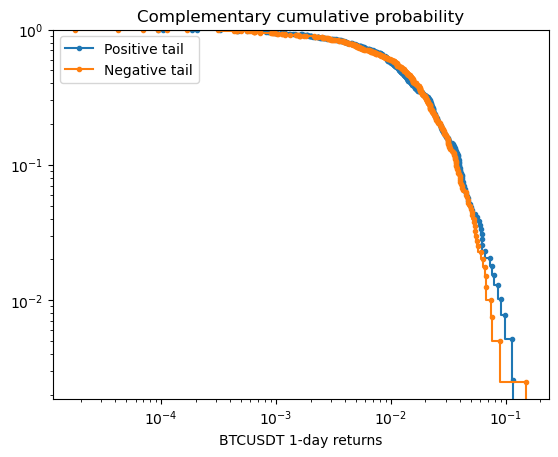

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
sample sizes: 390, 400
4.036074972344428+-0.409384265756541, 5.314151231791468+-0.9897341708700275


In [84]:
# Plot returns CCDF
cutoff = 1E-2 # Cutoff point at which the power-law tail starts was selected visually from the log-log plot of CCDF of returns

gains = []
losses = []
filteredgains = []
filteredlosses = []

# Find the 'return' r. Separate r values into gains and losses.
for j, price in enumerate(df['Price']):
    if j < len(df['Price'])-1:
        r = math.log(df['Price'][j+1]) - math.log(price)
        if r >= 0:
            gains.append(r)
            if r >= cutoff:
                filteredgains.append(r)
        else:
            losses.append(abs(r))
            if r <= -cutoff:
                filteredlosses.append(abs(r))

# Plot the complementary cumulative probability distribution of 'returns'
plt.ecdf(gains,complementary=True, marker='.', label='Positive tail')
plt.ecdf(losses,complementary=True, marker='.', label='Negative tail')

plt.title('Complementary cumulative probability')
plt.xlabel('BTCUSDT 1-day returns')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# Calculate exponent of tail values.
gain_alpha, gain_u= pl_fit(filteredgains)
loss_alpha, loss_u = pl_fit(filteredlosses)
print(f'sample sizes: {len(gains)}, {len(losses)}')
print(f'{gain_alpha}+-{gain_u}, {loss_alpha}+-{loss_u}')

In [ ]:
# Estimate Levy stable parameters

# Set time window of our study
crisisdate = '2025-10-10' # Date of crisis we want to study
window = 500 # Number of latest consecutive days to use in estimation of Levy stable parameters, up to crisisdate

crisisrow = np.where(df['Date'] == crisisdate)[0][0] # Row in df corresponding to crisisdate
windowrowend = crisisrow - 1 # Row in df corresponding to end of window, ie. 1 day before the crisis
windowrowstart = crisisrow - 1 - window # Row in df corresponding to start of window
windowprices = np.array(df['Price'].iloc[windowrowstart:windowrowend])
filteredreturns = []

# Find the 'return' r
for j, price in enumerate(windowprices):
    if j < len(windowprices)-1:
        r = math.log(windowprices[j+1]) - math.log(price)

        if r>=cutoff or r<=-cutoff:
            filteredreturns.append(r)

print(f'no. of filtered returns = {len(filteredreturns)}')
print(f'time period of window: {df['Date'].iloc[windowrowstart]} to {df['Date'].iloc[windowrowend]}')
print(f'alpha, beta = {crit_params(filteredreturns)}')

no. of filtered returns = 278
time period of window: 2024-05-27 to 2025-10-09
alpha, beta = (np.float64(2.0), np.float64(-1.0))
